# Read H-Reflex App Data Files

This notebook reads and visualizes data from the **H-Reflex Behavior App** (hreflex_txbdc) binary data files.

**V2 file convention (current):**
- **`.hrs1`** — MH Recruitment Curve stage: sweeps across stimulation intensities to map the M/H-wave recruitment curve.
- **`.hrs2`** — Control Mode stage: stimulates at a fixed user-set intensity (can be changed between trials).
- **`.hrs3`** — Down Condition Pellet (DCP) stage: closed-loop H-reflex conditioning with pellet reward.

**V1 file convention (legacy):**
- **`.hrs1`** — EMG Characterization stage: captures baseline EMG grand-mean distribution.
- **`.hrs2`** — MH Recruitment Curve stage (same binary format as V2 `.hrs1`).

All trial files share the MhRecHeader + MhRecTrial binary format.
EMG data blocks (raw differential, filtered, abs-value) are embedded in every file.

The binary format is based on the `FileIO_Helpers` serialization from the `hreflex_txbdc` package.

# Section 1: Binary File Reader Utilities

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from helpers import (
    # File readers
    read_hrs1, read_hrs2, read_hrs3, find_hrs_files, detect_app_version,
    # Summary printers
    print_hrs1_summary, print_hrs2_summary,
    # HRS2 plots
    plot_amplitude_distribution, plot_background_emg_views, plot_hrs2_analysis,
    plot_actual_trial_timeline,
    # SNR analysis
    compute_snr_analysis, compute_mra_snr_analysis,
    plot_hrs2_trials, classify_trials, get_trial_window,
    detect_stim_onset, get_trial_context_window,
    detect_and_correct_failed_trials,
    # Post-hoc global windowing analysis
    analyze_global_background, run_threshold_sweep, plot_threshold_sweep,
    split_trials_by_polarity, plot_hm_ratio_summary, plot_hwave_regression,
    # Constants
    SAMPLE_RATE, BIN_DURATION_MS, BIN_SAMPLES, TRIAL_RECORD_MS,
    STIM_ONSET_THRESHOLD, STIM_END_THRESHOLD,
    build_merged_amp_groups,
)

print("Helpers loaded.")
print(f"  App constants: SAMPLE_RATE={SAMPLE_RATE} Hz | BIN={BIN_DURATION_MS} ms ({BIN_SAMPLES} samples) | TRIAL_RECORD={TRIAL_RECORD_MS} ms")
print(f"  Stim thresholds: onset >= {STIM_ONSET_THRESHOLD} V | end < {STIM_END_THRESHOLD} V")

Helpers loaded.
  App constants: SAMPLE_RATE=5000.0 Hz | BIN=50 ms (250 samples) | TRIAL_RECORD=100 ms
  Stim thresholds: onset >= 4.5 V | end < 1.9 V


# Section 1b: Auto-Detect Recording Files

Set `recording_dir` to the path of your recording folder.  
The `.hrs1` and `.hrs2` files will be found automatically.

In [2]:
# C3_HRPILOT-18_BOOTH1_500US_6-22-26
# C4_HRPILOT-18_BOOTH1_500US_6-23-26
# C5_HRPILOT-18_BOOTH1_500US_6-24-26
# C6_HRPILOT-18_BOOTH1_500US_6-25-26
# C7_HRPILOT-18_BOOTH1_500US_6-26-26
# C8_HRPILOT-18_BOOTH1_500US_6-26-26

recording_dir         = "CC2_HRPILOT-18_BOOTH1_500US_6-30-26"
recording_sample_rate = 15000  # Set to e.g. 5000.0 or 10000.0 to override; None = auto-detect from HRS1 header

hrs1_path, hrs2_path, hrs3_path = find_hrs_files(recording_dir)
_app_version = detect_app_version(recording_dir)
print(f"H-Reflex App V{_app_version}  |  "
      f"hrs1={os.path.basename(hrs1_path) if hrs1_path else chr(8211)}  "
      f"hrs2={os.path.basename(hrs2_path) if hrs2_path else chr(8211)}  "
      f"hrs3={os.path.basename(hrs3_path) if hrs3_path else chr(8211)}")


H-Reflex App V2  |  hrs1=–  hrs2=CC2_HRPILOT-18_BOOTH1_500US_6-30-26_20260630T102937.hrs2  hrs3=–


In [3]:
# --- Load all data files (auto-detects V1 / V2 app) ---------------------------
cm_header  = cm_trials  = cm_emg_blocks  = None   # V2 Control Mode (None in V1)
dcp_header = dcp_trials = dcp_emg_blocks = None   # V2 Down Condition Pellet (None in V1)

if _app_version == 1:
    # V1: S1=EMG Characterization (.hrs1)  S2=MH Recruitment Curve (.hrs2)
    if hrs1_path:
        hrs1_header, hrs1_trials, hrs1_emg_blocks = read_hrs1(hrs1_path)
        print_hrs1_summary(hrs1_header, hrs1_trials, hrs1_emg_blocks, hrs1_path)
    else:
        print("No .hrs1 file found — EMG Characterization data unavailable.")
        hrs1_header, hrs1_trials, hrs1_emg_blocks = None, [], []
    if hrs2_path:
        hrs2_header, hrs2_trials, hrs2_emg_blocks = read_hrs2(hrs2_path)
        print_hrs2_summary(hrs2_header, hrs2_trials, hrs2_emg_blocks, hrs2_path)
    else:
        print("No .hrs2 file found — MH Recruitment data unavailable.")
        hrs2_header, hrs2_trials, hrs2_emg_blocks = None, [], []
else:
    # V2: S1=MH Recruitment (.hrs1, same binary as V1 .hrs2)
    #     S2=Control Mode (.hrs2)   S3=Down Condition Pellet (.hrs3)
    if hrs1_path:
        hrs2_header, hrs2_trials, hrs2_emg_blocks = read_hrs2(hrs1_path)
        hrs1_header = hrs2_header          # alias — no separate EMG char stage in V2
        hrs1_trials, hrs1_emg_blocks = [], []
        print_hrs2_summary(hrs2_header, hrs2_trials, hrs2_emg_blocks, hrs1_path)
    else:
        print("No .hrs1 file found — MH Recruitment data unavailable.")
        hrs1_header = hrs2_header = None
        hrs1_trials = hrs2_trials = []
        hrs1_emg_blocks = hrs2_emg_blocks = []
    if hrs2_path:
        cm_header, cm_trials, cm_emg_blocks = read_hrs2(hrs2_path)
        print(f"Control Mode:           {len(cm_trials)} trials")
    else:
        print("No .hrs2 file found — Control Mode data unavailable.")
    if hrs3_path:
        dcp_header, dcp_trials, dcp_emg_blocks = read_hrs3(hrs3_path)
        print(f"Down Condition Pellet:  {len(dcp_trials)} trials")
    else:
        print("No .hrs3 file found — Down Condition Pellet data unavailable.")


# V2 Control Mode-only: no Recruitment Curve stage (.hrs1 absent).
# Alias hrs2_trials <- cm_trials so all downstream analysis cells work unchanged.
if _app_version == 2 and not hrs2_trials and cm_trials:
    hrs2_header     = cm_header
    hrs2_trials     = cm_trials
    hrs2_emg_blocks = cm_emg_blocks
    hrs1_header     = hrs2_header
    print('Note: Control Mode trials used as primary analysis (no Recruitment Curve stage).')

# Ensure hrs1_header.sample_rate is always accessible for downstream cells
if hrs1_header is None:
    class _SampleRateStub:
        sample_rate = recording_sample_rate or 5000.0
    hrs1_header = _SampleRateStub()


No .hrs1 file found — MH Recruitment data unavailable.
Control Mode:           766 trials
No .hrs3 file found — Down Condition Pellet data unavailable.
Note: Control Mode trials used as primary analysis (no Recruitment Curve stage).


# Section 3: Peri-Stimulus Trials — MH Recruitment Curve or Control Mode

For **V2** recordings `hrs2_trials` contains whichever stage was run:
- `.hrs1` present → MH Recruitment Curve trials
- `.hrs1` absent, `.hrs2` present → Control Mode trials (aliased automatically)

For **V1** recordings `hrs2_trials` contains the MH Recruitment Curve trials from `.hrs2`.

In [4]:
# Data already loaded in the cell above.
# hrs2_trials = MH Recruitment Curve trials (V1 or V2).
print(f"MH Recruitment trials : {len(hrs2_trials)}"
      + (f"  |  Control Mode: {len(cm_trials)}" if cm_trials  is not None else "")
      + (f"  |  DCP: {len(dcp_trials)}"         if dcp_trials is not None else ""))


MH Recruitment trials : 766  |  Control Mode: 766


Available stages:
  'control_mode'         → Control Mode (.hrs2)  (766 trials)  ◄ active

Active : Control Mode (.hrs2)  ·  766 trials
(Change ACTIVE_STAGE above + re-run this cell only when switching stages for Post-Hoc analysis.)

── Histogram: Control Mode (.hrs2)  (766 trials)


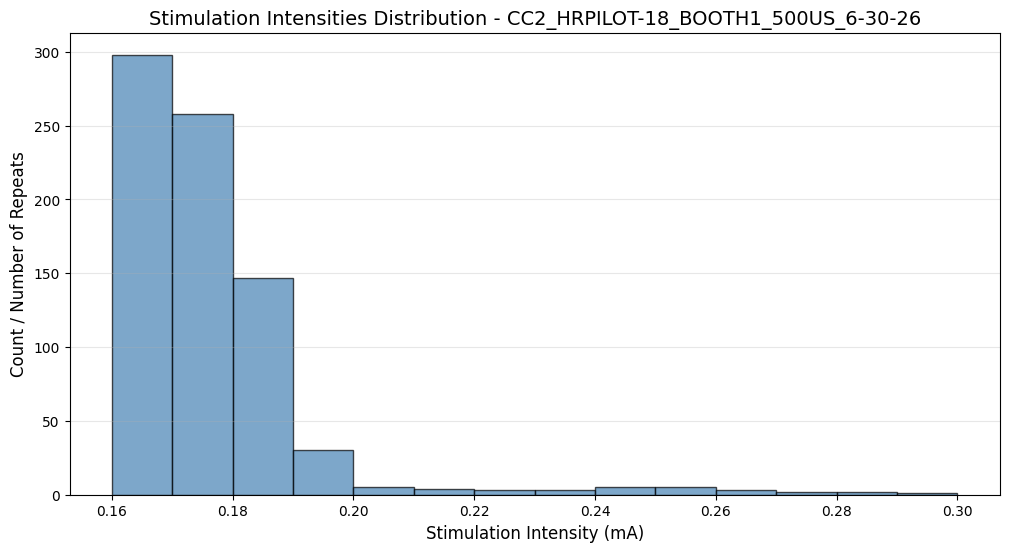

In [5]:
# ── Stage Selector + Stimulation Intensity Histogram ──────────────────────────
# ACTIVE_STAGE controls which stage the Post-Hoc notebook (and _plot_trials below) uses.
# All viewer cells further down show a Stage dropdown when multiple stages are loaded.

_stage_map = {}
if hrs2_trials and (not cm_trials or hrs2_trials is not cm_trials):
    _stage_map['mh_recruitment'] = (hrs2_trials, hrs2_header, hrs2_emg_blocks,
                                     'MH Recruitment Curve (.hrs1)')
if cm_trials:
    _stage_map['control_mode']   = (cm_trials,   cm_header,   cm_emg_blocks,
                                     'Control Mode (.hrs2)')
if dcp_trials:
    _stage_map['dcp']            = (dcp_trials,  dcp_header,  dcp_emg_blocks,
                                     'Down Condition Pellet (.hrs3)')

ACTIVE_STAGE = next(iter(_stage_map))   # default: first available stage
# ACTIVE_STAGE = 'mh_recruitment'        # MH Recruitment Curve  (.hrs1)
# ACTIVE_STAGE = 'control_mode'          # Control Mode          (.hrs2)
# ACTIVE_STAGE = 'dcp'                   # Down Condition Pellet (.hrs3)

if ACTIVE_STAGE not in _stage_map:
    ACTIVE_STAGE = next(iter(_stage_map))
    print(f'Note: requested stage not available; defaulting to {ACTIVE_STAGE!r}')

_sel = _stage_map[ACTIVE_STAGE]
_plot_trials, _plot_header, _plot_emg_blocks = _sel[0], _sel[1], _sel[2]

print('Available stages:')
for _k, (_t, _h, _e, _lbl) in _stage_map.items():
    _mark = '  ◄ active' if _k == ACTIVE_STAGE else ''
    print(f'  {_k!r:<22} → {_lbl}  ({len(_t)} trials){_mark}')
print(f'\nActive : {_sel[3]}  ·  {len(_plot_trials)} trials')
print('(Change ACTIVE_STAGE above + re-run this cell only when switching stages for Post-Hoc analysis.)')

# ── Stimulation Intensity Histogram ───────────────────────────────────────
from ipywidgets import Dropdown, VBox, Output
from IPython.display import display as _disp

_hist_opts = [(lbl, sk) for sk, (_t, _h, _e, lbl) in _stage_map.items() if _t]
if len(_hist_opts) == 1:
    _sk, (_st, _sh, _se, _slbl) = next(iter(_stage_map.items()))
    print(f'\n── Histogram: {_slbl}  ({len(_st)} trials)')
    plot_amplitude_distribution(_st, _sh)
else:
    _hist_out  = Output()
    _hist_drop = Dropdown(options=_hist_opts, description='Stage:', layout={'width': '440px'})
    def _hist_show(change=None):
        _st, _sh, _se, _slbl = _stage_map[_hist_drop.value]
        with _hist_out:
            _hist_out.clear_output(wait=True)
            print(f'\n── Histogram: {_slbl}  ({len(_st)} trials)')
            plot_amplitude_distribution(_st, _sh)
    _hist_drop.observe(_hist_show, names='value')
    _disp(VBox([_hist_drop, _hist_out]))
    _hist_show()



── Trial Timeline: Control Mode (.hrs2)  (766 trials)
Actual trial timeline (766 trials)
  Recording span : 9983.5 s  (2.773 h)
  Trial rate     : 276.2 trials / hour
  ITI — mean: 13050 ms  |  median: 5399 ms  |  min: 4607 ms  |  max: 489549 ms


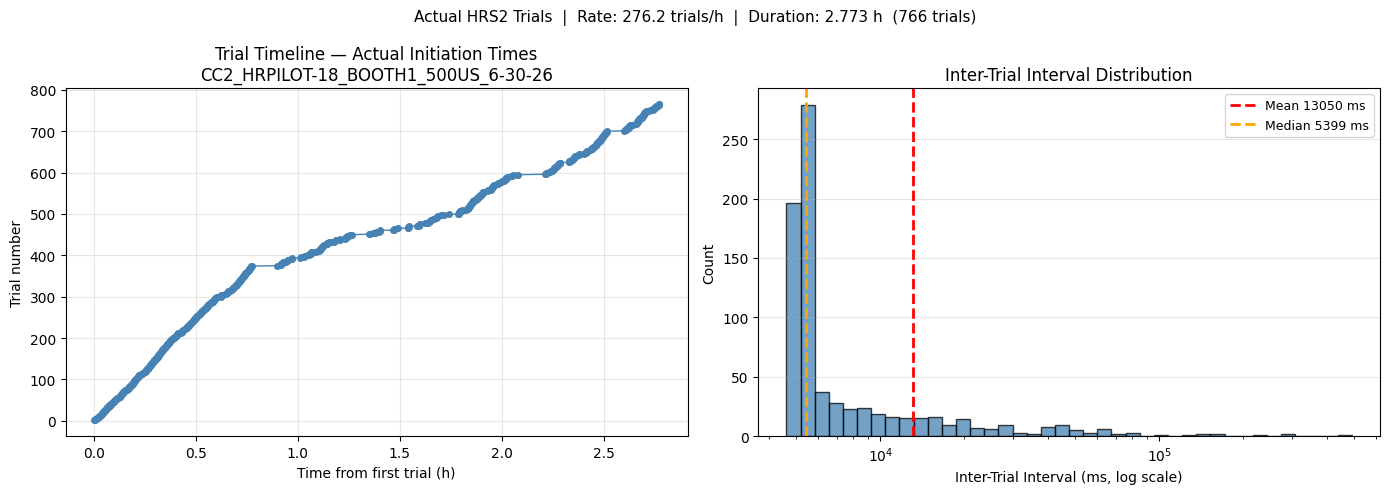

In [6]:
# ── Trial Timeline ─────────────────────────────────────────────────────────
# Shows trial number vs. actual wall-clock time and inter-trial interval (ITI)
# distribution for each recording stage.
from ipywidgets import Dropdown, VBox, Output
from IPython.display import display as _disp

_tl_opts = [(lbl, sk) for sk, (_t, _h, _e, lbl) in _stage_map.items() if _t]
if len(_tl_opts) == 1:
    _sk, (_st, _sh, _se, _slbl) = next(iter(_stage_map.items()))
    print(f'\n── Trial Timeline: {_slbl}  ({len(_st)} trials)')
    plot_actual_trial_timeline(_st, header=_sh)
else:
    _tl_out  = Output()
    _tl_drop = Dropdown(options=_tl_opts, description='Stage:', layout={'width': '440px'})
    def _tl_show(change=None):
        _st, _sh, _se, _slbl = _stage_map[_tl_drop.value]
        with _tl_out:
            _tl_out.clear_output(wait=True)
            print(f'\n── Trial Timeline: {_slbl}  ({len(_st)} trials)')
            plot_actual_trial_timeline(_st, header=_sh)
    _tl_drop.observe(_tl_show, names='value')
    _disp(VBox([_tl_drop, _tl_out]))
    _tl_show()


# Section 3b: "Most Recent Background" + "Background EMG Level"

Recreates the H-Reflex App recruitment-curve trial-plot widgets from `MhRecruitmentCurveStage.get_trial_plot_options`:

- **Most recent background** â€” bar chart of the pre-stim |EMG| bins.
- **EMG Level** â€” scatter of background grand means across trials.

Bins are reconstructed from `hrs2_emg_blocks` over a fixed monitoring window (default 2500 ms ending at trigger time).

In [7]:
# ── Background EMG Views ──────────────────────────────────────────────────
from ipywidgets import Dropdown, VBox, Output
from IPython.display import display as _disp

_bg_opts = [(lbl, sk) for sk, (_t, _h, _e, lbl) in _stage_map.items() if _t]
if len(_bg_opts) == 1:
    _sk, (_st, _sh, _se, _slbl) = next(iter(_stage_map.items()))
    print(f'\n── Background EMG: {_slbl}  ({len(_st)} trials)')
    plot_background_emg_views(_st, _se, monitoring_window_ms=2500)
else:
    _bg_out  = Output()
    _bg_drop = Dropdown(options=_bg_opts, description='Stage:', layout={'width': '440px'})
    def _bg_show(change=None):
        _st, _sh, _se, _slbl = _stage_map[_bg_drop.value]
        with _bg_out:
            _bg_out.clear_output(wait=True)
            print(f'\n── Background EMG: {_slbl}  ({len(_st)} trials)')
            plot_background_emg_views(_st, _se, monitoring_window_ms=2500)
    _bg_drop.observe(_bg_show, names='value')
    _disp(VBox([_bg_drop, _bg_out]))
    _bg_show()



── Background EMG: Control Mode (.hrs2)  (766 trials)
766 trials used stored bins  |  0 trials reconstructed from emg_blocks.


# Section 6: HRS2 Detailed Analysis

Interactive averaged-waveform paged grid (with M/H peak markers and signal overlays) plus the normalized and raw recruitment curves. The cell below sets the analysis parameters; the cell after that calls `plot_hrs2_analysis`.

In [8]:
#  Configuration 
PRE_PLOT_MS  = 5   # ms before stim onset to display
POST_PLOT_MS = 25  # ms after  stim onset to display
N_PER_PAGE   = 6   # trials shown per page (2 rows x 3 cols)

# M/H wave window constants (ms relative to stim onset)
#M_WAVE_START_MS = 3
#M_WAVE_END_MS= 5.5
#H_WAVE_START_MS = 9.0
#H_WAVE_END_MS   = 12

M_WAVE_START_MS = 1.8 
M_WAVE_END_MS= 5 
H_WAVE_START_MS = 7
H_WAVE_END_MS   = 12

PRE_AVG_MS  = 5   # ms before stim onset
POST_AVG_MS = 25  # ms after  stim onset
N_PER_PAGE  = 6   # amplitude groups per page (2 rows x 3 cols)


In [9]:
# ── Optional: Merged Amplitude Group Analysis ─────────────────────────────
# Pool multiple stimulation intensities into one merged group.
# MERGED_GROUPS is a list of lists, e.g.:
#   [[0.12, 0.13], [0.15, 0.16, 0.17]]  →  two merged groups
# Leave as [] to use the default (unmerged) grouping.
MERGED_GROUPS = []

if MERGED_GROUPS:
    _hrs2_trials_plot = build_merged_amp_groups(_plot_trials, MERGED_GROUPS)
else:
    _hrs2_trials_plot = _plot_trials


In [ ]:
# ── HRS2 Analysis: Interactive Averaged Waveforms + Recruitment Curve ─────
from ipywidgets import Dropdown, VBox, Output
from IPython.display import display as _disp

_ana_opts = [(lbl, sk) for sk, (_t, _h, _e, lbl) in _stage_map.items() if _t]
if len(_ana_opts) == 1:
    _sk, (_st, _sh, _se, _slbl) = next(iter(_stage_map.items()))
    _tp = build_merged_amp_groups(_st, MERGED_GROUPS) if MERGED_GROUPS else _st
    print(f'\n── Analysis: {_slbl}  ({len(_st)} trials)')
    plot_hrs2_analysis(
        _tp, _sh,
        pre_avg_ms=PRE_AVG_MS, post_avg_ms=POST_AVG_MS,
        n_per_page=N_PER_PAGE,
        m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
        h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
        sample_rate=recording_sample_rate or hrs1_header.sample_rate,
        emg_blocks=_se,
    )
else:
    _ana_out  = Output()
    _ana_drop = Dropdown(options=_ana_opts, description='Stage:', layout={'width': '440px'})
    def _ana_show(change=None):
        _st, _sh, _se, _slbl = _stage_map[_ana_drop.value]
        _tp = build_merged_amp_groups(_st, MERGED_GROUPS) if MERGED_GROUPS else _st
        with _ana_out:
            _ana_out.clear_output(wait=True)
            print(f'\n── Analysis: {_slbl}  ({len(_st)} trials)')
            plot_hrs2_analysis(
                _tp, _sh,
                pre_avg_ms=PRE_AVG_MS, post_avg_ms=POST_AVG_MS,
                n_per_page=N_PER_PAGE,
                m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
                h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
                sample_rate=recording_sample_rate or hrs1_header.sample_rate,
                emg_blocks=_se,
            )
    _ana_drop.observe(_ana_show, names='value')
    _disp(VBox([_ana_drop, _ana_out]))
    _ana_show()



── Analysis: Control Mode (.hrs2)  (766 trials)
Loaded 14 amplitude groups across 3 page(s).
Double-click a subplot to zoom in. Ctrl-click to select multiple signals.


Output()

HTML(value='<hr><b>Background EMG — selected amplitude / polarity group</b>')

Output()

HTML(value='<hr><b>H-wave Regression — selected amplitude / polarity group</b>')

Output()

In [11]:
# ── HRS2 Trial Viewer: Interactive Per-Trial Grid + Zoom ─────────────────
from ipywidgets import Dropdown, VBox, Output
from IPython.display import display as _disp

_trv_opts = [(lbl, sk) for sk, (_t, _h, _e, lbl) in _stage_map.items() if _t]
if len(_trv_opts) == 1:
    _sk, (_st, _sh, _se, _slbl) = next(iter(_stage_map.items()))
    _tp = build_merged_amp_groups(_st, MERGED_GROUPS) if MERGED_GROUPS else _st
    print(f'\n── Trial Viewer: {_slbl}  ({len(_st)} trials)')
    plot_hrs2_trials(
        _tp, _sh,
        pre_plot_ms=PRE_PLOT_MS, post_plot_ms=POST_PLOT_MS,
        n_per_page=N_PER_PAGE,
        m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
        h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
        sample_rate=recording_sample_rate or hrs1_header.sample_rate,
        emg_blocks=_se,
    )
else:
    _trv_out  = Output()
    _trv_drop = Dropdown(options=_trv_opts, description='Stage:', layout={'width': '440px'})
    def _trv_show(change=None):
        _st, _sh, _se, _slbl = _stage_map[_trv_drop.value]
        _tp = build_merged_amp_groups(_st, MERGED_GROUPS) if MERGED_GROUPS else _st
        with _trv_out:
            _trv_out.clear_output(wait=True)
            print(f'\n── Trial Viewer: {_slbl}  ({len(_st)} trials)')
            plot_hrs2_trials(
                _tp, _sh,
                pre_plot_ms=PRE_PLOT_MS, post_plot_ms=POST_PLOT_MS,
                n_per_page=N_PER_PAGE,
                m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
                h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
                sample_rate=recording_sample_rate or hrs1_header.sample_rate,
                emg_blocks=_se,
            )
    _trv_drop.observe(_trv_show, names='value')
    _disp(VBox([_trv_drop, _trv_out]))
    _trv_show()



── Trial Viewer: Control Mode (.hrs2)  (766 trials)
Loaded 766 trials across 128 page(s).
Sample rate: 15000 Hz  |  ms/sample: 0.0667
Stim waveform: available
Double-click a subplot to zoom in, or use the dropdown + 'View trial' button.


HTML(value='<hr><b>Background EMG — selected group</b>')

Output()

HTML(value='<hr><b>H:M Ratio Summary — selected group</b>')

Output()

HTML(value='<hr><b>H-wave Regression — selected group</b>')

Output()

# Section 3c: H:M Ratio Summary

Box plot and histogram of H:M ratio for each stimulation polarity group.
If both normal and reversed polarities were used in this session, each group is analysed separately.


── Polarity / H:M Ratio: Control Mode (.hrs2)  (766 trials)
Single-polarity session (config 1 only): 766 reversed trials.


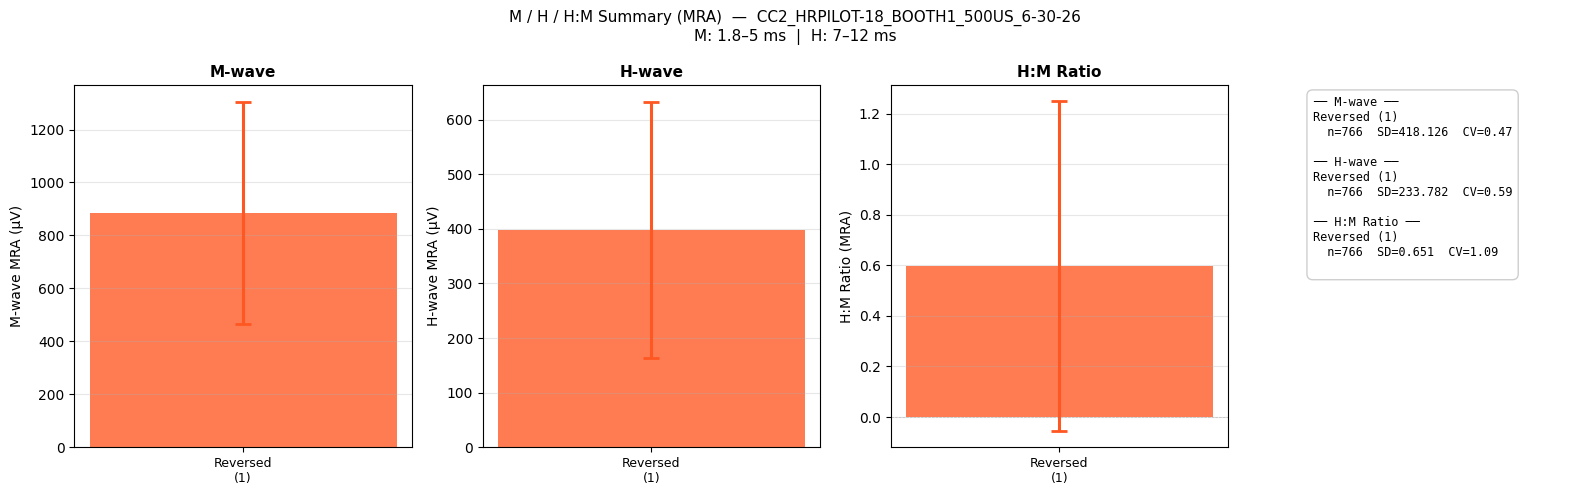

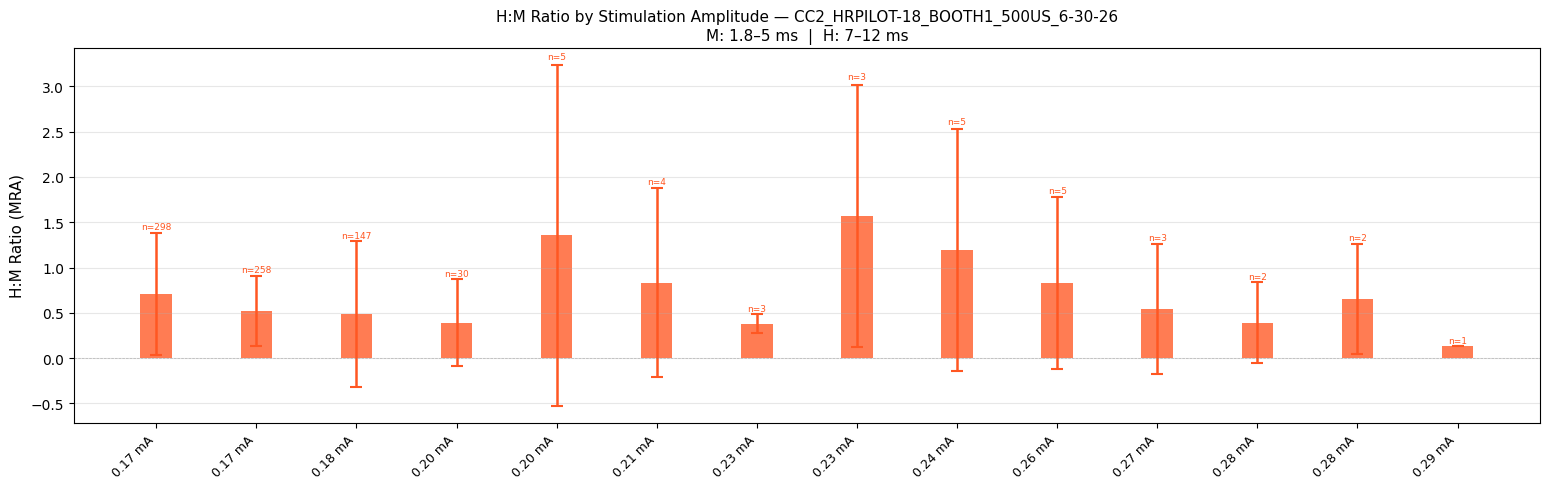

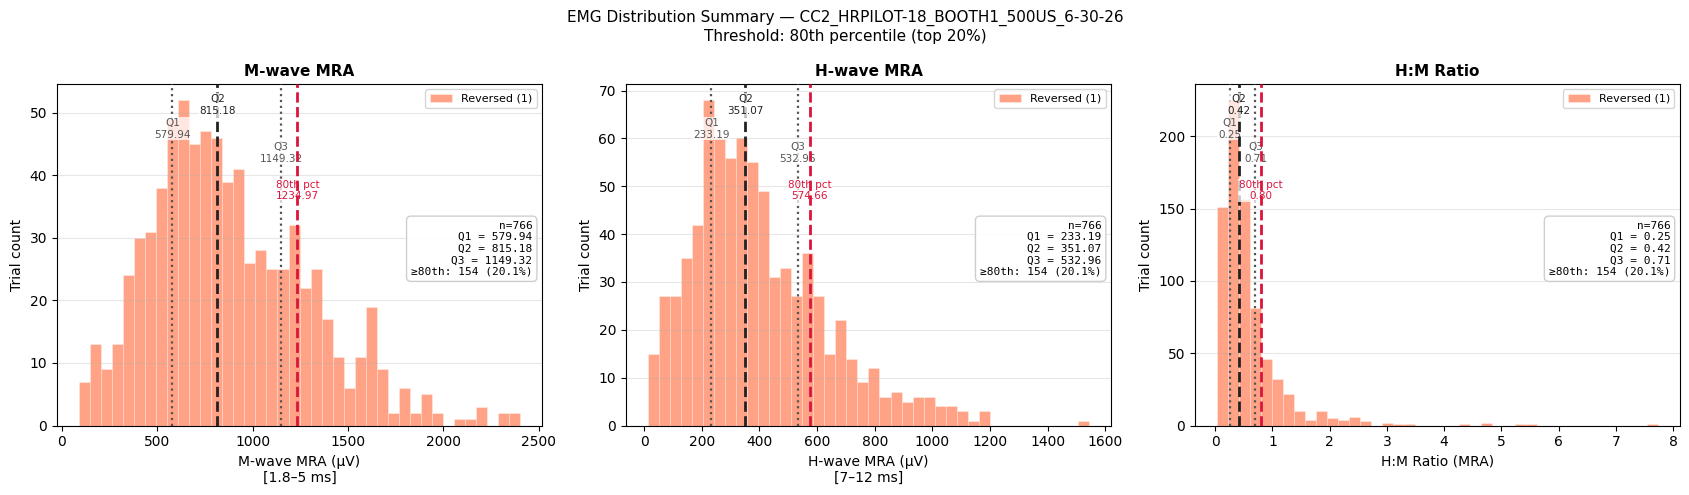

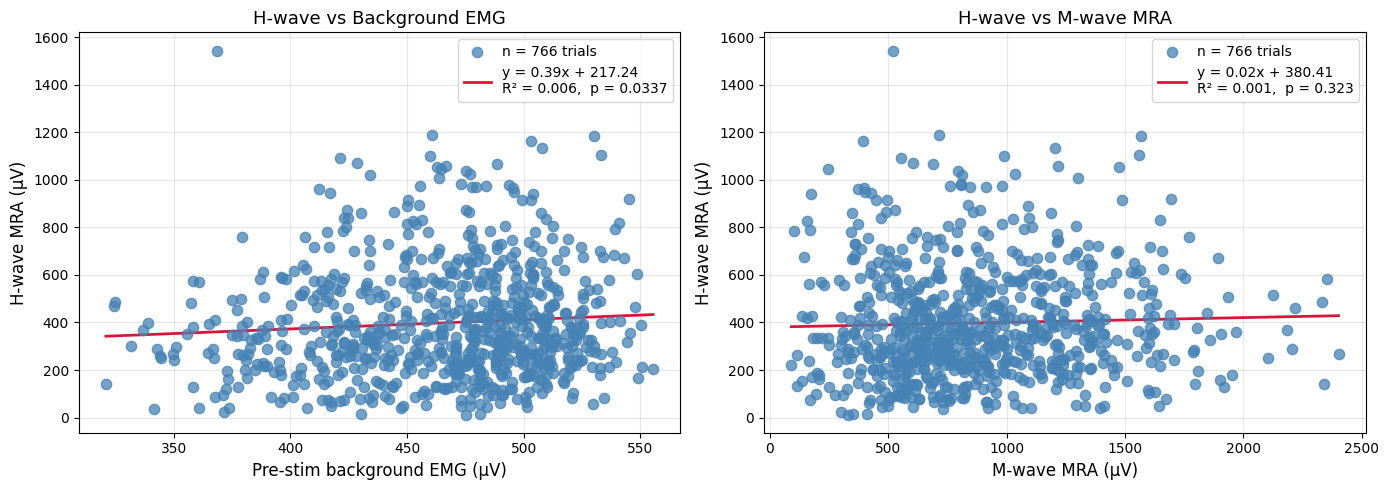

  Regression (n=766):  slope=0.3889  intercept=217.24  R²=0.0059  p=0.03367


In [12]:
# ── Stim Polarity Analysis ───────────────────────────────────────────────
from ipywidgets import Dropdown, VBox, Output
from IPython.display import display as _disp

_pol_opts = [(lbl, sk) for sk, (_t, _h, _e, lbl) in _stage_map.items() if _t]
if len(_pol_opts) == 1:
    _sk, (_st, _sh, _se, _slbl) = next(iter(_stage_map.items()))
    print(f'\n── Polarity / H:M Ratio: {_slbl}  ({len(_st)} trials)')
    trials_by_polarity = split_trials_by_polarity(_st)
    plot_hm_ratio_summary(
        trials_by_polarity, _sh,
        m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
        h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
        sample_rate=recording_sample_rate or hrs1_header.sample_rate,
        pre_ms=PRE_AVG_MS, post_ms=POST_AVG_MS,
    )
    plot_hwave_regression(
        _st, _se,
        m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
        h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
        sample_rate=recording_sample_rate or hrs1_header.sample_rate,
        pre_ms=PRE_AVG_MS, post_ms=POST_AVG_MS,
    )
else:
    _pol_out  = Output()
    _pol_drop = Dropdown(options=_pol_opts, description='Stage:', layout={'width': '440px'})
    def _pol_show(change=None):
        _st, _sh, _se, _slbl = _stage_map[_pol_drop.value]
        with _pol_out:
            _pol_out.clear_output(wait=True)
            print(f'\n── Polarity / H:M Ratio: {_slbl}  ({len(_st)} trials)')
            trials_by_polarity = split_trials_by_polarity(_st)
            plot_hm_ratio_summary(
                trials_by_polarity, _sh,
                m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
                h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
                sample_rate=recording_sample_rate or hrs1_header.sample_rate,
                pre_ms=PRE_AVG_MS, post_ms=POST_AVG_MS,
            )
            plot_hwave_regression(
                _st, _se,
                m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
                h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
                sample_rate=recording_sample_rate or hrs1_header.sample_rate,
                pre_ms=PRE_AVG_MS, post_ms=POST_AVG_MS,
            )
    _pol_drop.observe(_pol_show, names='value')
    _disp(VBox([_pol_drop, _pol_out]))
    _pol_show()
